In [1]:
library(Signac)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(GenomicRanges)
library(rtracklayer)
library(tidyr)
library(tibble)
library(future)

# Set up multithreading for faster processing
plan("multicore", workers = 16)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.2”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.

In [2]:
setwd('/gpfs/commons/groups/vickovic_lab/rhe/projects/005/space_tag_reproducibility/fig2')

#### Figure 2d: Change in chromatin state distribution across differential histone peaks

In [3]:
state_annotations <- c(
  'E1' = 'none',
  'E2' = 'repressive',
  'E3' = 'none',
  'E4' = 'none',
  'E5' = 'heterochromatin',
  'E6' = 'none',
  'E7' = 'heterochromatin',
  'E8' = 'poised',
  'E9' = 'enhancer',
  'E10' = 'none',
  'E11' = 'enhancer',
  'E12' = 'enhancer',
  'E13' = 'active',
  'E14' = 'promoter',
  'E15' = 'promoter'
)

diff_peaks_dir <- 'processed_data/differential_peaks'
model_dir <- 'processed_data/aging_brain_chromhmm_trained_model_15'

annotation_levels_all <- c('isocortex', 'fiber_tracts', 'hypothalamus', 'hippocampus', 'thalamus', 'striatum')
annotation_order_plot <- c('thalamus', 'isocortex', 'hypothalamus', 'fiber tracts')
age_order <- c('12m', '18m', '24m')
state_order <- c('repressive', 'heterochromatin', 'poised', 'enhancer', 'active', 'promoter')

state_col_map <- c(
  repressive = '#4FAD5B',
  heterochromatin = '#9AE099',
  poised = '#CA74C7',
  enhancer = '#ADC9E9',
  active = '#224760',
  promoter = '#6093D3'
)

state_label_map <- c(
  repressive = 'repressive',
  heterochromatin = 'hetero-\nchromatin',
  poised = 'poised',
  enhancer = 'enhancer',
  active = 'active',
  promoter = 'promoter'
)

sample_label_map <- c(
  thalamus = 'THA',
  isocortex = 'ISO',
  hypothalamus = 'HYP',
  'fiber tracts' = 'FIB'
)

In [4]:
read_peak_granges <- function(filename) {
  peak_df <- read.delim(
    filename,
    header = TRUE,
    row.names = 1,
    check.names = FALSE,
    stringsAsFactors = FALSE,
    blank.lines.skip = TRUE
  )

  if (nrow(peak_df) == 0) {
    return(GenomicRanges::GRanges())
  }

  Signac::StringToGRanges(rownames(peak_df))
}

In [5]:
de_peaks_list <- list()

for (annotation in annotation_levels_all) {
  annotation_files <- list.files(
    file.path(diff_peaks_dir, annotation),
    pattern = '_DE_peaks\\.bed$',
    full.names = TRUE
  )

  annotation_de_peaks <- lapply(annotation_files, read_peak_granges)
  annotation_de_peaks <- annotation_de_peaks[lengths(annotation_de_peaks) > 0]

  if (length(annotation_de_peaks) == 0) {
    de_peaks_list[[annotation]] <- GenomicRanges::GRanges()
  } else {
    de_peaks_list[[annotation]] <- reduce(do.call(c, annotation_de_peaks))
  }
}

segment_files <- list.files(model_dir, pattern = '_15_segments\\.bed$', full.names = FALSE)
segment_file_map <- setNames(segment_files, gsub('_15_segments\\.bed$', '', segment_files))
names(segment_file_map) <- gsub('fiber_tracts', 'fiber tracts', names(segment_file_map))
segment_file_map <- segment_file_map[grepl('^(fiber tracts|isocortex|hypothalamus|thalamus)_', names(segment_file_map))]

Warning message in .merge_two_Seqinfo_objects(x, y):
“The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrY
  - in 'y': chr1, chr3, chr8, chr10, chr14
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrY
  - in 'y': chr2, chr4, chr5, chr6, chr7, chr9, chr12, chr13, chr15, chr17, chr18, chr19
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr9, chr17

In [6]:
states <- list()

for (sample in names(segment_file_map)) {
  region <- stringr::str_split_fixed(sample, '_', 2)[, 1]
  region_key <- gsub('fiber tracts', 'fiber_tracts', region)
  query_peaks <- de_peaks_list[[region_key]]

  if (length(query_peaks) == 0) {
    states[[sample]] <- GenomicRanges::GRanges()
    next
  }

  all_chromhmm_states <- rtracklayer::import.bed(
    file.path(model_dir, segment_file_map[[sample]]),
    which = query_peaks
  )

  if (length(all_chromhmm_states) == 0) {
    states[[sample]] <- GenomicRanges::GRanges()
    next
  }

  gr2_split <- GenomicRanges::intersect(query_peaks, GenomicRanges::disjoin(all_chromhmm_states))

  if (length(gr2_split) == 0) {
    states[[sample]] <- GenomicRanges::GRanges()
    next
  }

  hits <- GenomicRanges::findOverlaps(gr2_split, all_chromhmm_states)
  mcols(gr2_split)$name <- NA_character_
  mcols(gr2_split)$name[queryHits(hits)] <- as.character(mcols(all_chromhmm_states)$name[subjectHits(hits)])

  gr_out <- gr2_split
  gr_out$name <- state_annotations[as.character(gr_out$name)]
  states[[sample]] <- gr_out
}

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrX
  - in 'y': chrM
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chrX
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrX
  - in 'y': chrM
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
 

In [7]:
prop_by_sample <- bind_rows(lapply(names(states), function(sample) {
  gr <- states[[sample]]

  if (length(gr) == 0) {
    return(tibble(sample = sample, state = state_order, width = 0, prop = NA_real_))
  }

  state_values <- as.character(mcols(gr)$name)
  total_width <- sum(width(reduce(gr)))

  state_widths <- vapply(state_order, function(state_name) {
    state_gr <- gr[state_values == state_name]
    if (length(state_gr) == 0) {
      return(0)
    }
    sum(width(reduce(state_gr)))
  }, numeric(1))

  tibble(
    sample = sample,
    state = state_order,
    width = state_widths,
    prop = if (total_width > 0) state_widths / total_width else NA_real_
  )
}))

prop_plot_df <- prop_by_sample %>%
  mutate(
    sample_name = stringr::str_split_fixed(sample, '_', 2)[, 1],
    age = factor(stringr::str_split_fixed(sample, '_', 2)[, 2], levels = c('3m', age_order))
  )

prop_rel_df <- prop_plot_df %>%
  group_by(sample_name, state) %>%
  mutate(baseline = prop[age == '3m'][1]) %>%
  ungroup() %>%
  mutate(relative_prop = ifelse(is.na(baseline) | baseline == 0, NA_real_, prop - baseline)) %>%
  filter(age != '3m', sample_name %in% annotation_order_plot, state %in% state_order) %>%
  mutate(
    sample_name = factor(sample_name, levels = annotation_order_plot),
    state = factor(state, levels = state_order),
    age = factor(as.character(age), levels = age_order)
  )

plot_grid_df <- tidyr::expand_grid(
  sample_name = factor(annotation_order_plot, levels = annotation_order_plot),
  state = factor(state_order, levels = state_order),
  age = factor(age_order, levels = age_order)
) %>%
  left_join(
    prop_rel_df %>% select(sample_name, state, age, relative_prop),
    by = c('sample_name', 'state', 'age')
  )

bar_df <- plot_grid_df %>% filter(!is.na(relative_prop))

y_limit <- max(0.32, max(abs(bar_df$relative_prop), na.rm = TRUE) * 1.08)

bar_df <- bar_df %>%
  mutate(
    state_panel = factor(as.character(state), levels = state_order, labels = unname(state_label_map[state_order])),
    sample_panel = factor(as.character(sample_name), levels = annotation_order_plot, labels = unname(sample_label_map[annotation_order_plot]))
  )


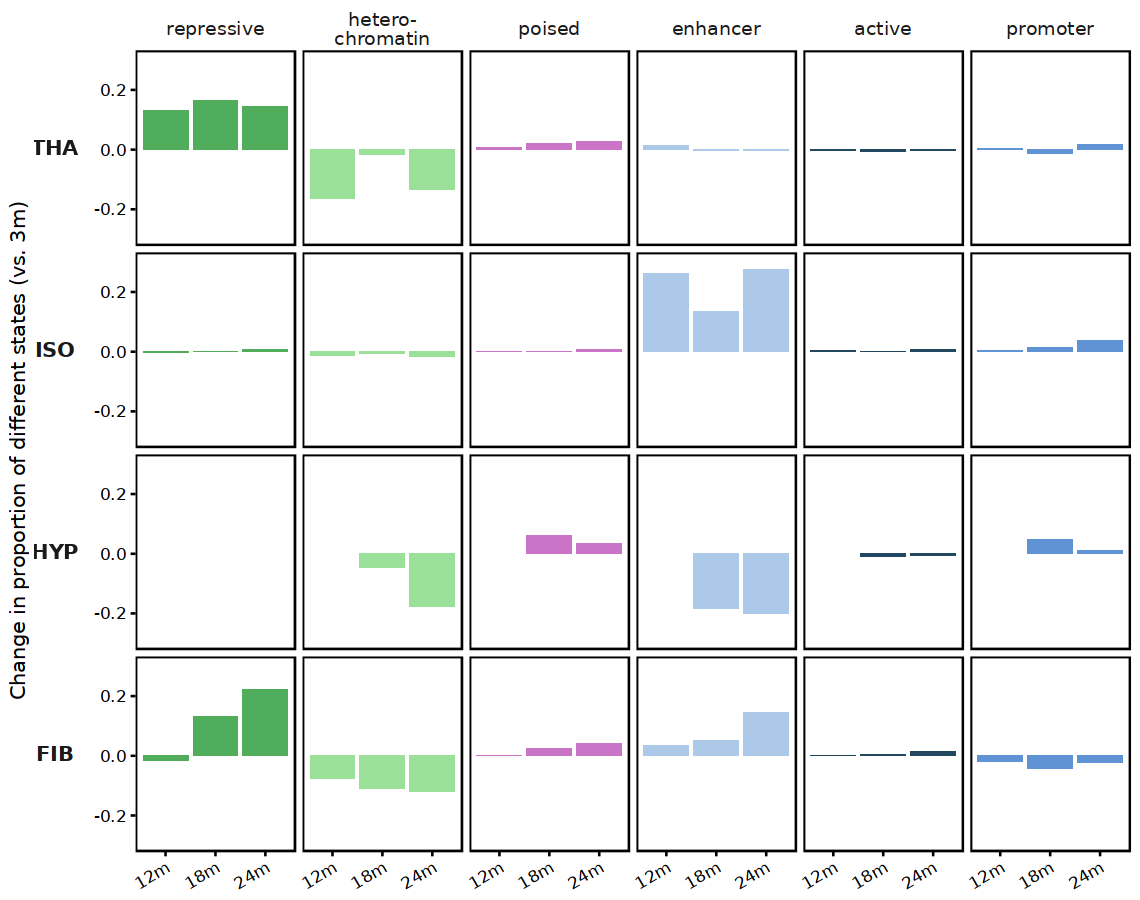

In [ ]:
options(repr.plot.width = 9.5, repr.plot.height = 7.5)

p <- ggplot(bar_df, aes(x = age, y = relative_prop, fill = state)) +
  geom_col(width = 0.9) +
  facet_grid(sample_panel ~ state_panel, switch = 'y', drop = FALSE) +
  scale_fill_manual(values = state_col_map, guide = 'none') +
  scale_y_continuous(
    limits = c(-y_limit, y_limit),
    breaks = c(-0.2, 0, 0.2),
    expand = expansion(mult = c(0, 0.02))
  ) +
  xlab(NULL) +
  ylab('Change in proportion of different states (vs. 3m)') +
  theme_classic(base_size = 12) +
  theme(
    panel.border = element_rect(fill = NA, color = 'black', linewidth = 0.8),
    panel.spacing = grid::unit(0.3, 'lines'),
    strip.background = element_blank(),
    strip.placement = 'outside',
    strip.text.x = element_text(size = 11, margin = margin(b = 2)),
    strip.text.y.left = element_text(angle = 0, face = 'bold', size = 12, margin = margin(r = 8)),
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1),
    axis.line = element_blank(),
    legend.position = 'none'
  )

print(p)